<a href="https://colab.research.google.com/github/nidhisharma1398-byte/Ecommerce-Churn-Prediction/blob/main/Ecommerce_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving E Commerce Dataset.csv to E Commerce Dataset (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv('E Commerce Dataset.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [ ]:
# Check shape and basic info
print("shape:",df.shape)
print("\n")
print(df.info())

shape: (5630, 20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13

In [ ]:
# Check missing values clearly
print(df.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [ ]:
# Fill missing  vakues with median
num_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed','OrderCount','DaySinceLastOrder']
for col in num_cols:

  df[col].fillna(df[col].median(),inplace=True)
  # Verify no missing values remain
  print(df.isnull().sum())

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64
CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered      

/tmp/ipykernel_2553/196727035.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [ ]:
print(df.columns.tolist())

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


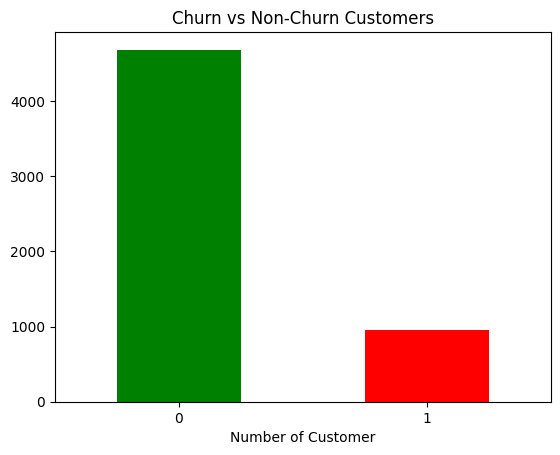

Churn
0    4682
1     948
Name: count, dtype: int64

Churn %: 16.84 %


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# churn distribution
df['Churn'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Churn vs Non-Churn Customers')
plt.xlabel('Number of Customer')
plt.xticks(rotation=0)
plt.show()
print(df['Churn'].value_counts())
print("\nChurn %:",round(df['Churn'].mean()*100,2),"%")

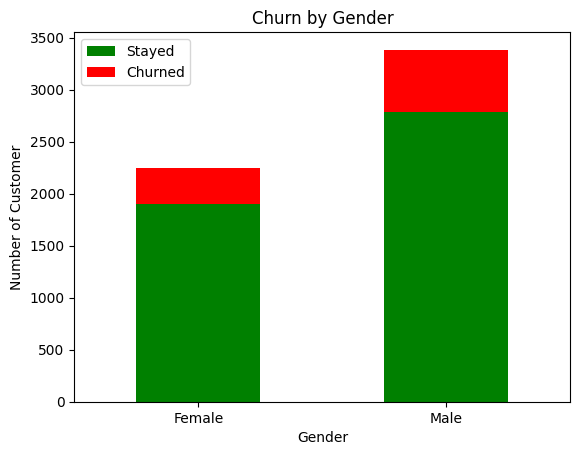

In [ ]:
# Churn by Gender
df.groupby(['Gender','Churn']).size().unstack().plot(kind='bar',stacked=True,color=['green','red'])

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customer')
plt.legend(['Stayed','Churned'])
plt.xticks(rotation=0)
plt.show()

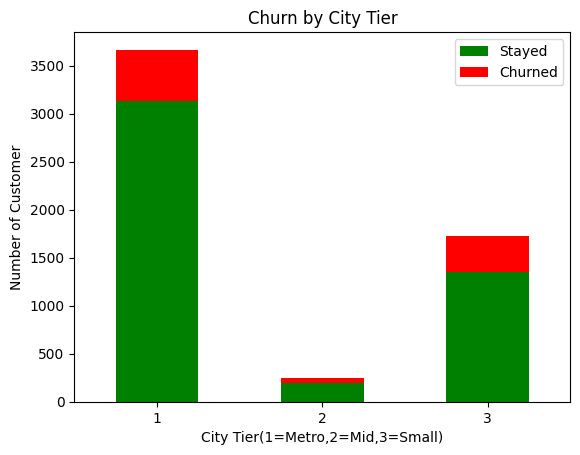

In [ ]:
# Churn by City Tier
df.groupby(['CityTier','Churn']).size().unstack().plot(kind='bar',stacked=True,color=['green','red'])

plt.title('Churn by City Tier')
plt.xlabel('City Tier(1=Metro,2=Mid,3=Small)')
plt.ylabel('Number of Customer')
plt.legend(['Stayed','Churned'])
plt.xticks(rotation=0)
plt.show()

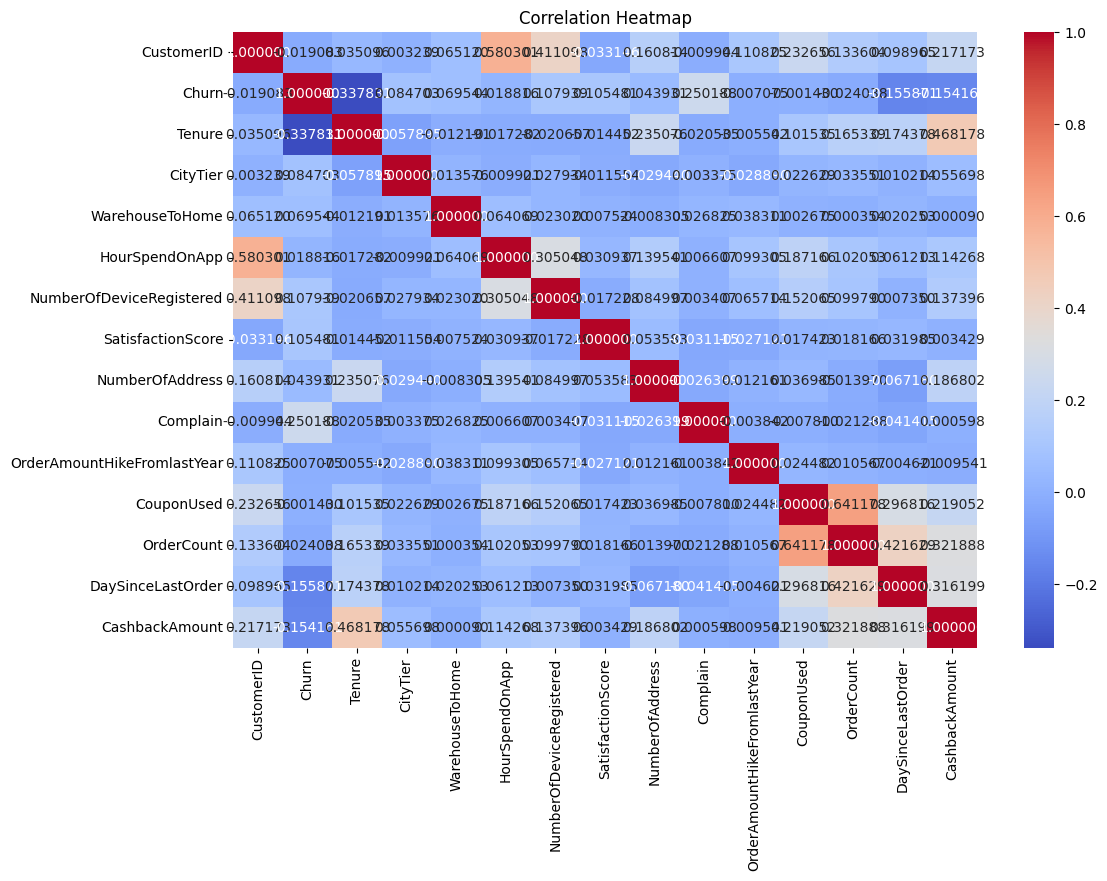

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
numeric_df=df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),annot=True,fmt='2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
#Encode categorical columns
le=LabelEncoder()
# Automatically find and encode all text columns
cat_cols=df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
  df[col]=le.fit_transform(df[col])
  print("\nEncoding done!")
  print(df.head())


Encoding done!
   CustomerID  Churn  Tenure  PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0                     1         3              6.0   
1       50002      1     9.0                     2         1              8.0   
2       50003      1     9.0                     2         1             30.0   
3       50004      1     0.0                     2         3             15.0   
4       50005      1     0.0                     2         1             12.0   

   PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0                     4       0             3.0                         3   
1                     6       1             3.0                         4   
2                     4       1             2.0                         4   
3                     4       1             2.0                         4   
4                     0       1             3.0                         3   

   PreferedOrderCat  SatisfactionS

In [ ]:
print(df.columns.tolist())

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [ ]:
from sklearn.model_selection import train_test_split
# Separate features and target
x=df.drop(['CustomerID','Churn'],axis=1)
y=df['Churn']
# Split data
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training size:",X_train.shape)
print("Testing size:",X_test.shape)

Training size: (4504, 18)
Testing size: (1126, 18)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
# Model 1: Logistic Regression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print("Logistic Regression Accuracy:",round(accuracy_score(y_test,y_pred_lr)*100,2),"%")
#Model 2: Random Forest
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print("Ranndom Forest Accuracy:",round(accuracy_score(y_test,rf_pred)*100,2),"%")
# Model 3 :XGBoost
xgb=XGBClassifier(random_state=42)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
print("XGBoost Accuracy:",round(accuracy_score(y_test,xgb_pred)*100,2),"%")


Logistic Regression Accuracy: 89.08 %
Ranndom Forest Accuracy: 98.05 %
XGBoost Accuracy: 98.05 %


===XGBoost Evaluation===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       941
           1       0.97      0.91      0.94       185

    accuracy                           0.98      1126
   macro avg       0.97      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



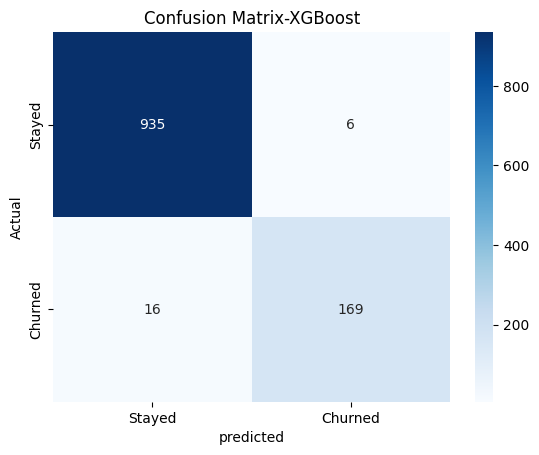

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
# XGBoost detailed evaluation
print("===XGBoost Evaluation===")
print(classification_report(y_test,xgb_pred))
# Confusion Matrix
cm=confusion_matrix(y_test,xgb_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Stayed','Churned'],yticklabels=['Stayed','Churned'])
plt.title('Confusion Matrix-XGBoost')
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.show()

In [ ]:
# feature importance - XGBoost
feat_imp = pd.Series(xgb.feature_importances_,index=X.columns)
feat_imp.nlargest(10).plot(kind='barh',color='steelblue')
plt.title('Top 10 Important Features- XGBooost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

NameError: name 'X' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('E Commerce Dataset.csv')

# Clean missing values
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split data
X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

print("All done! Ready to plot.")

Saving E Commerce Dataset.csv to E Commerce Dataset (1).csv
All done! Ready to plot.


/tmp/ipykernel_2553/2456723793.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


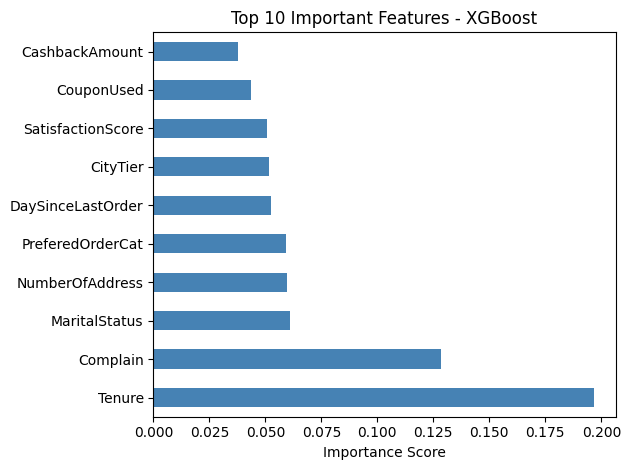

In [ ]:
# Feature Importance - XGBoost
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()